In [445]:
import datetime as dt
import math
import matplotlib.pyplot as plt
import meteostat
import numpy as np
import pandas as pd
import requests
import statistics
import warnings; warnings.simplefilter('ignore')
import xgboost as xgb

from category_encoders import TargetEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score

import os
import sys
sys.path.insert(0, os.path.abspath(
    os.path.join(os.path.dirname('__file__'), '..')))
from src.encoding.encoders import *
from src.encoding.tools import create_encoding_pipeline


In [446]:
def weighted_rmse_obj(y_true: np.ndarray, y_pred: np.ndarray):
    """
    Custom objective function for RMSE weighted by deviation from mean.
    
    Parameters:
    y_true (array): True values.
    y_pred (array): Predicted values.
    
    Returns:
    grad (array): Gradient of the loss.
    hess (array): Hessian (second derivative) of the loss.
    """

    mean = np.mean(y_true)
    std = np.std(y_true)
    
    # Calcul des poids en fonction de l'écart par rapport à la moyenne
    weights = 1 + (np.abs(y_true - mean) / std)
    
    errors = y_pred - y_true
    grad = weights * errors
    hess = weights
    
    return grad, hess

def percentiles_weighted_rmse_obj(y_true: np.ndarray, y_pred: np.ndarray):
    """
    Custom percentiles weighted RMSE objective function.
    
    Parameters:
    y_true (array): True values.
    y_pred (array): Predicted values.
    
    Returns:
    grad (array): Gradient of the loss.
    hess (array): Hessian (second derivative) of the loss.
    """
    percentile_95 = np.percentile(y_true, 95)
    percentile_90 = np.percentile(y_true, 90)
    percentile_85 = np.percentile(y_true, 85)
    percentile_80 = np.percentile(y_true, 80)
    percentile_75 = np.percentile(y_true, 75)
    percentile_70 = np.percentile(y_true, 70)
    percentile_65 = np.percentile(y_true, 65)
    percentile_60 = np.percentile(y_true, 60)
    percentile_55 = np.percentile(y_true, 55)
    percentile_50 = np.percentile(y_true, 50)
    
    weights = np.ones_like(y_true)
    weights[y_true > percentile_55] = 1.5
    weights[y_true > percentile_60] = 2
    weights[y_true > percentile_65] = 2.5
    weights[y_true > percentile_70] = 4
    weights[y_true > percentile_75] = 4.5
    weights[y_true > percentile_80] = 5
    weights[y_true > percentile_85] = 5.5
    weights[y_true > percentile_90] = 6
    weights[y_true > percentile_95] = 6.5
    # weights[y_true < percentile_5] = 5   # Poids plus élevé pour les creux


    errors = y_pred - y_true
    grad = weights * errors
    hess = weights
    
    return grad, hess

def percentiles_weighted_rmse(y_true, y_pred):
    """
    Custom evaluation metric for percentiles weighted RMSE.
    
    Parameters:
    y_true (ndarray): True target values.
    y_pred (ndarray): Predicted values.

    Returns:
    weighted_rmse_value (float): Value of the weighted RMSE.
    """
    percentile_95 = np.percentile(y_true, 95)
    percentile_90 = np.percentile(y_true, 90)
    percentile_85 = np.percentile(y_true, 85)

    # Appliquer une interpolation linéaire entre les percentiles.
    # L'utilisation des valeurs booléennes doit être réécrite avec des opérations logiques.
    diff = np.logical_xor(y_true, y_pred).astype(int)  # Correction pour les booléens
    weighted_rmse_value = np.sqrt(np.mean(diff ** 2))

    return weighted_rmse_value


def weighted_rmse(y_true, y_pred):
    """
    Custom evaluation metric for RMSE weighted by deviation from mean.
    
    Parameters:
    y_true (array): True values.
    y_pred (array): Predicted values.
    
    Returns:
    weighted_rmse_value (float): Value of the weighted RMSE.
    """

    
    mean = np.mean(y_true)
    std = np.std(y_true)
    
    # Calcul des poids en fonction de l'écart par rapport à la moyenne
    weights = 1 + (np.abs(y_true - mean) / std)

    # print(weights)

    errors = y_pred - y_true
    weighted_squared_errors = weights * errors ** 2
    weighted_rmse_value = np.sqrt(np.mean(weighted_squared_errors))
    
    return weighted_rmse_value

def percentiles_weighted_rmse(y_true, y_pred):
    """
    Custom evaluation metric for percentiles weighted RMSE.
    
    Parameters:
    y_true (array): True values.
    y_pred (array): Predicted values.
    
    Returns:
    weighted_rmse_value (float): Value of the weighted RMSE.
    """
    
    percentile_95 = np.percentile(y_true, 95)
    percentile_90 = np.percentile(y_true, 90)
    percentile_85 = np.percentile(y_true, 85)
    percentile_80 = np.percentile(y_true, 80)
    percentile_75 = np.percentile(y_true, 75)
    percentile_70 = np.percentile(y_true, 70)
    percentile_65 = np.percentile(y_true, 65)
    percentile_60 = np.percentile(y_true, 60)
    percentile_55 = np.percentile(y_true, 55)
    percentile_50 = np.percentile(y_true, 50)
    
    weights = np.ones_like(y_true)
    weights[y_true > percentile_55] = 1.5
    weights[y_true > percentile_60] = 2
    weights[y_true > percentile_65] = 2.5
    weights[y_true > percentile_70] = 4
    weights[y_true > percentile_75] = 4.5
    weights[y_true > percentile_80] = 5
    weights[y_true > percentile_85] = 5.5
    weights[y_true > percentile_90] = 6
    weights[y_true > percentile_95] = 6.5

    # print(weights)

    errors = y_pred - y_true
    weighted_squared_errors = weights * errors ** 2
    weighted_rmse_value = np.sqrt(np.mean(weighted_squared_errors))
    
    return weighted_rmse_value

def temporal_weighted_rmse_obj(y_true, y_pred):
    # Penalize based on whether the prediction lags the true value
    lag_penalty = np.where(y_pred < y_true, 2.0, 1.0)
    errors = y_pred - y_true
    grad = lag_penalty * errors
    hess = lag_penalty
    return grad, hess


def peak_detection_metric(y_true, y_pred):
    peak_threshold = np.percentile(y_true, 90)
    true_peaks = y_true > peak_threshold
    pred_peaks = y_pred > peak_threshold
    precision = precision_score(true_peaks, pred_peaks)
    recall = recall_score(true_peaks, pred_peaks)
    f1 = f1_score(true_peaks, pred_peaks)
    return f1  

metrique = percentiles_weighted_rmse

In [447]:
params = {'objective': percentiles_weighted_rmse_obj, 
                  'early_stopping_round':15,
                  'learning_rate': 0.1,
                  'eval_metric': metrique, 
                  #'reg_alpha': 1.0, 
                  #'reg_lambda': 1.0,
                  'max_depth': 6, 
                  #'min_child_weight': 5,
                  #'subsample': 0.8, 
                  #'colsample_bytree': 0.8
                 }

type_target = 'hospitalisations'
assert type_target in ['hospitalisations', 'arrivees_urgences']
horizon = 15
NUM_FEATS = 50

reg = xgb.XGBRegressor()
reg.set_params(**params)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_round=15,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=<function percentiles_weighted_rmse at 0x136803400>,
             feature_types=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [448]:
def teste(df, params):
    means, metriques = [], []
    for random_state in range(42, 45):
        train_val_set, test_set = train_test_split(df, test_size=0.2, random_state=random_state)
        train_set, val_set = train_test_split(train_val_set, test_size=0.2, random_state=random_state)
        
        X_train = train_set.drop('target', axis=1)
        y_train = train_set['target']
        X_val = val_set.drop('target', axis=1)
        y_val = val_set['target']
        X_test = test_set.drop('target', axis=1)
        y_test = test_set['target']
        reg.fit(X_train, y_train,
                eval_set=[(X_val, y_val)],
                verbose=False)
        means.append(mean_absolute_error(reg.predict(X_test), y_test))
        metriques.append(metrique(reg.predict(X_test), y_test))
    #return (statistics.mean(means), statistics.mean(rmses)) 
    return (min(means), min(metriques)) 

In [449]:
%pylab inline
pylab.rcParams['figure.figsize'] = (18, 8)

global_year = {'predict': [], 'actual': []}

def teste_final(df, params, start, stop, plot=True):
    global global_year
    test_set = df.loc[(df.index>=start)&(df.index<=stop)]
    train_val_set = df.loc[(df.index<start)|(df.index>stop)]
    train_val_set = df.loc[df.index<start]
    train_set, val_set = train_test_split(train_val_set, test_size=0.2)
    X_train = train_set.drop('target', axis=1)
    y_train = train_set['target']
    X_val = val_set.drop('target', axis=1)
    y_val = val_set['target']
    X_test = test_set.drop('target', axis=1)
    y_test = test_set['target']
    reg.fit(X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False)
    y_pred = reg.predict(X_test)
    global_year['predict'].extend(list(y_pred))
    global_year['actual'].extend(list(y_test))
    if plot:
        plt.figure()
        plt.ylim(0, 250)
        plt.plot(X_test.index, y_pred, label='predicted')
        plt.plot(X_test.index, y_test, label='actual')
        plt.legend()
        plt.title(f"MAE : {mean_absolute_error(reg.predict(X_test), y_test)}")
        plt.show()
        if start.month==11:
            xgb.plot_importance(reg)
            fig = matplotlib.pyplot.gcf()
            fig.set_size_inches(10, 10)
            fig.show()
    #print(f" MAE finale : {mean_absolute_error(reg.predict(X_test), y_test)}")
    return [(X_test.index, y_pred), (X_test.index, y_test), reg]

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [450]:
def select_features(df0, target='target', num_feats=100):
    df = df0.copy()
    nan_columns = [(k, df[k].isna().sum()) for k in df if df[k].isna().sum()>0]
    if len(nan_columns) > 0:
        enregistre_exception(f'Il y a des colonnes avec des nan : {nan_columns}', to_file=False)
        print(f"Taille de df avant suppression des colonnes de NaN: {df.shape}")
        df = df.dropna(axis=1)
        print(f"Taille de df après suppression des colonnes de NaN: {df.shape}")
    # On enlève les colonnes de target
    if df.shape[1]-1 < num_feats:
        enregistre_exception(f"Pas assez de features ({df.shape[1]} pour {num_feats} à sélectionner)", to_file=False)
        num_feats = df.shape[1]-1
    print("=> Recherche des features pertinentes")
    '''
    print("   - Grande variance")
    variances = df.var()
    high_variance = list(variances[variances > 0.5].index)
    if target in high_variance:
        high_variance.remove(target)
    '''
    print("   - Coefficient de corrélation de Pearson")
    correlations = sorted([(k, abs(df[k].corr(df[target]))) for k in df.columns if k not in [target]], key=lambda x:x[1], reverse=True)
    #correlations = sorted([(k, abs(np.corrcoef(df[k], df[target])[0,1])) for k in df.columns if k not in [target]], key=lambda x:x[1], reverse=True)
    Liste_Pearson = [u[0] for u in correlations if u[1] >= 0.4]
    print("   - Coefficient de corrélation de Kendall")
    method = 'kendall'
    correlations = sorted([(k, abs(df[[k, target]].corr(method=method).values[0,1])) for k in df.columns 
                                if k not in [target, 'date']], key=lambda x:x[1], reverse=True)
    Liste_Kendall = [u[0] for u in correlations if u[1] >= 0.4]
    print("   - Coefficient de corrélation de Spearman")
    method = 'spearman'
    correlations = sorted([(k, abs(df[[k, target]].corr(method=method).values[0,1])) for k in df.columns 
                                if k not in [target, 'date']], key=lambda x:x[1], reverse=True)
    Liste_Spearman = [u[0] for u in correlations if u[1] >= 0.4]
    X = df.drop(target, axis=1)
    y = df[target]
    print("   - Random forests")
    dico = dict(n_estimators=100, max_depth=7)
    dico.update(n_jobs=-1)
    embeded_rf_selector = SelectFromModel(
                    RandomForestRegressor(**dico),
                    max_features=num_feats)
    embeded_rf_selector.fit(X, y)
    embeded_rf_support = embeded_rf_selector.get_support()
    embeded_rf_feature = X.loc[:, embeded_rf_support].columns.tolist()
    print("   - Régression linéaire")    
    embeded_lr_selector = SelectFromModel(LinearRegression(),max_features=num_feats)
    embeded_lr_selector.fit(X, y)
    embeded_lr_support = embeded_lr_selector.get_support()
    true_indices = embeded_lr_support.nonzero()[0].tolist()
    embeded_lr_feature = [X.columns[i] for i in true_indices]
    '''
    print("   - Chi-2 selector")
    X = df.drop(target, axis=1)
    y = df[target]
    X_norm = MinMaxScaler().fit_transform(X)
    chi_selector = SelectKBest(chi2, k=num_feats)
    chi_selector.fit(X_norm, y)
    chi_support = chi_selector.get_support()
    chi_feature = X.loc[:, chi_support].columns.tolist()
    '''
    print("   - Extra trees")
    model = ExtraTreesRegressor(n_jobs=-1, max_depth=7)
    model.fit(X,y)
    feat_importances = pd.Series(model.feature_importances_, index=X.columns)
    xt_features = list(feat_importances.nlargest(num_feats).index)
    print("   - XGBoost")
    train_set, val_set = train_test_split(df, test_size=0.2)
    X_train = train_set.drop(target, axis=1)
    X_val = val_set.drop(target, axis=1)
    y_train = train_set[target]
    y_val = val_set[target]
    dico_xgb = {'max_depth': 7, 'early_stopping_rounds':6, 'n_estimators': 100000}
    reg = xgb.XGBRegressor(**dico_xgb)
    reg.fit(X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False)
    a, b = X_train.columns, reg.feature_importances_
    res_xgb = sorted([(a[k], b[k]) for k in range(len(X.columns))], key=lambda x:x[1], reverse=True)
    features_xgb = [k[0] for k in res_xgb[:num_feats]]
    print("   - Lasso")
    rfe_selector = RFE(estimator=Lasso(alpha=0.1),
                    n_features_to_select=num_feats,
                    step=100, verbose=5)
    rfe_selector.fit(X, y)
    rfe_support = rfe_selector.get_support()
    rfe_feature = X.loc[:,rfe_support].columns.tolist()
    #total = Liste_Pearson+Liste_Kendall+Liste_Spearman+embeded_lr_feature+embeded_rf_feature+chi_feature+xt_features+features_xgb+rfe_feature
    total = Liste_Pearson+Liste_Kendall+Liste_Spearman+embeded_lr_feature+embeded_rf_feature+xt_features+features_xgb+rfe_feature
    total = sorted(set([(k, total.count(k)) for k in total if total.count(k)>1]), key=lambda x:x[1], reverse=True)[:num_feats]
    print(f"Classement final: {total}")
    '''
    final = [k for k in total if k[0]=='en_cours']
    final.extend([k for k in total if 'en_cours_' in k[0]])
    final.extend([k for k in total if k[0] in [f'interv-{k}' for k in range(1,6)]])
    final.extend([k for k in total if k[0] in [f'appels-{k}' for k in range(1,6)]])
    final.extend([k for k in total if k[0] in [f'appels_somme-{k}' for k in range(1,6)]])
    final.extend([k for k in total if k[0] in ['hour', 'dayofweek', 'dayofyear']])
    final.extend([k for k in total if 'interv-' not in k[0] 
        and 'appels-' not in k[0] and k[0] not in [u[0] for u in final]])
    final.extend([k for k in total if k[0] not in [u[0] for u in final]])
    '''
    autoregressif = [k for k in total if 'interventions' in k[0] or 'en_cours' in k[0]]
    tendances = [k for k in total if 'moving_average' in k[0]]
    hexogenes = [k for k in total if k not in autoregressif and k not in tendances]
    final = []
    '''
    for k in range(max([len(autoregressif), len(tendances), len(hexogenes)])):
        if k <= len(tendances)-1:
            final.append(tendances[k][0])
        if k <= len(hexogenes)-1:
            final.append(hexogenes[k][0])    
        if k <= len(autoregressif)-1:
            final.append(autoregressif[k][0])
    '''
    for col in total:
        final.append(col[0])
    return final


In [451]:
assert type_target in ['hospitalisations', 'arrivees_urgences']
if type_target == 'hospitalisations':
    '''
    df = pd.read_csv('target.csv', sep=';')
    '''
    df = pd.read_csv('RPU_vers_hospit_adultes.csv', sep=';')
    df['date_entree'] = pd.to_datetime(df['date_entree'], format="%d/%m/%Y")
    df.rename({'Total': type_target}, axis=1, inplace=True)
    df['target'] = df[type_target].copy()
    # on ajoute les arrivées aux urgences, que l'on suppose connues pour le jour J
    dff = pd.read_feather('CHU Dijon_volumes.feather')
    dff.rename({'Total': 'arrivees_urgences'}, axis=1, inplace=True)
    dff.reset_index(inplace=True)
    df = pd.merge(df, dff, on='date_entree')
else:
    df = pd.read_feather('CHU Dijon_volumes.feather')
    df.rename({'Total': type_target}, axis=1, inplace=True)
    df['target'] = df[type_target].copy()

In [452]:
if horizon > 1:
    window = df['target'].rolling(window=horizon)
    df[f'target-{horizon}'] = window.mean()
    df.drop('target', axis=1, inplace=True)
    df.rename({f'target-{horizon}': 'target'}, axis=1, inplace=True)
    df.bfill(inplace=True)

In [453]:
dg = pd.read_csv('features_all_origin.csv', sep=',')

In [454]:
dg.drop('Total', axis=1, inplace=True)

In [455]:
dg['date_entree'] = pd.to_datetime(dg['date_entree'], format="%Y-%m-%d")

In [456]:
df = pd.merge(df, dg, on='date_entree', how='left')

In [457]:
print(f"Baseline : {mean_absolute_error(df['target'], [df['target'].mean()]*len(df))}")

Baseline : 2.7975550914201466


In [458]:
df['target'].std()

4.796614733495446

In [459]:
df['target'].mean()

40.21069733479372

In [460]:
df.set_index('date_entree', inplace=True)

In [461]:
df['HNFC_moving'] = df['HNFC_moving']=='Après'

In [462]:
#df

In [463]:
df.drop('nom_etablissement_x', axis=1, inplace=True)
df.drop('nom_etablissement_y', axis=1, inplace=True)

In [464]:
df['day_of_week'] = df.index.dayofweek
df['day_of_year'] = df.index.dayofyear
dg = df.copy()

In [465]:
shifted = dg[type_target].shift(1)
window = shifted.rolling(window=30)
dg['month'] = window.mean()
dg.bfill(inplace=True)

In [466]:
def pendant_couvrefeux(date):
    # Fonction testant is une date tombe dans une période de confinement
    if ((dt.datetime(2020, 12, 15) <= date <= dt.datetime(2021, 1, 2)) 
        and (date.hour >= 20 or date.hour <= 6)):
        return 1
    elif ((dt.datetime(2021, 1, 2) <= date <= dt.datetime(2021, 3, 20))
        and (date.hour >= 18 or date.hour <= 6)):
            return 1
    elif ((dt.datetime(2021, 3, 20) <= date <= dt.datetime(2021, 5, 19))
        and (date.hour >= 19 or date.hour <= 6)):
            return 1
    elif ((dt.datetime(2021, 5, 19) <= date <= dt.datetime(2021, 6, 9))
        and (date.hour >= 21 or date.hour <= 6)):
            return 1
    elif ((dt.datetime(2021, 6, 9) <= date <= dt.datetime(2021, 6, 30))
        and (date.hour >= 23 or date.hour <= 6)):
            return 1
    return 0

dg['date'] = df.index.copy()
dg['confinement1'] = dg.date.apply(lambda x: 1 if dt.datetime(2020, 3, 17, 12) <= x <= dt.datetime(2020, 5, 11) else 0)
dg['confinement2'] = dg.date.apply(lambda x: 1 if dt.datetime(2020, 10, 30) <= x <= dt.datetime(2020, 12, 15) else 0)
dg['couvrefeux'] = dg.date.apply(pendant_couvrefeux)
dg.drop('date', axis=1, inplace=True)

In [467]:
window = shifted.rolling(window=365)
dg['year'] = window.mean()
dg.bfill(inplace=True)

In [468]:
for k in range(1,8):
    dg[f'history-{k}'] = dg[type_target].shift(k)

dg.bfill(inplace=True)

In [469]:
dg['decale'] = dg[type_target].shift(1)
for taille in range(2, 10):
    window = dg['decale'].rolling(window=taille)
    dg[f'average-{taille}'] = window.mean()

In [470]:
dg.drop('decale', axis=1, inplace=True)
dg.bfill(inplace=True)

In [471]:
# On ne connaît pas le nombre d'hospitalisation (resp. d'arrivées) du jour J
dg.drop(type_target, axis=1, inplace=True)

dg.drop('total_CHU Dijon', axis=1, inplace=True)

dg

,arrivees_urgences,target,bankHolidays,eveBankHolidays,holidays,borderHolidays,confinement1,confinement2,couvrefeux,ramadan,...,history-6,history-7,average-2,average-3,average-4,average-5,average-6,average-7,average-8,average-9
date_entree,,,,,,,,,,,,,,,,,,,,,
2019-01-01,202,46.200000,1.0,0.0,1.0,0.0,0,0,0,0.0,...,46.0,46.0,48.0,46.666667,47.25,46.0,46.166667,46.142857,47.500,46.666667
2019-01-02,198,46.200000,0.0,0.0,1.0,0.0,0,0,0,0.0,...,46.0,46.0,48.0,46.666667,47.25,46.0,46.166667,46.142857,47.500,46.666667
2019-01-03,186,46.200000,0.0,0.0,1.0,0.0,0,0,0,0.0,...,46.0,46.0,48.0,46.666667,47.25,46.0,46.166667,46.142857,47.500,46.666667
2019-01-04,186,46.200000,0.0,0.0,1.0,0.0,0,0,0,0.0,...,46.0,46.0,47.0,46.666667,47.25,46.0,46.166667,46.142857,47.500,46.666667
2019-01-05,204,46.200000,0.0,0.0,1.0,0.0,0,0,0,0.0,...,46.0,46.0,46.5,47.666667,47.25,46.0,46.166667,46.142857,47.500,46.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-27,165,40.133333,0.0,0.0,1.0,0.0,0,0,0,0.0,...,51.0,41.0,39.5,39.000000,39.00,39.6,41.500000,41.428571,42.375,42.000000
2023-12-28,192,40.400000,0.0,0.0,1.0,0.0,0,0,0,0.0,...,42.0,51.0,36.5,38.333333,38.25,38.4,39.000000,40.714286,40.750,41.666667
2023-12-29,157,40.866667,0.0,0.0,1.0,0.0,0,0,0,0.0,...,39.0,42.0,41.0,39.666667,40.25,39.8,39.666667,40.000000,41.375,41.333333


In [472]:
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.feature_selection import SelectFromModel, SelectKBest, chi2, RFE
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import log_loss, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler

liste = select_features(dg, num_feats = NUM_FEATS)

=> Recherche des features pertinentes
   - Coefficient de corrélation de Pearson
   - Coefficient de corrélation de Kendall
   - Coefficient de corrélation de Spearman
   - Random forests
   - Régression linéaire
   - Extra trees
   - XGBoost
   - Lasso
Fitting estimator with 1110 features.
Fitting estimator with 1010 features.
Fitting estimator with 910 features.
Fitting estimator with 810 features.
Fitting estimator with 710 features.
Fitting estimator with 610 features.
Fitting estimator with 510 features.
Fitting estimator with 410 features.
Fitting estimator with 310 features.
Fitting estimator with 210 features.
Fitting estimator with 110 features.
Classement final: [('month', 8), ('average-9', 8), ('average-8', 8), ('average-7', 7), ('average-5', 6), ('average-6', 6), ('average-4', 5), ('average-3', 5), ('history-7', 4), ('history-3', 4), ('history-6', 4), ('total_CHU Dijon_mean', 4), ('history-4', 4), ('inc_diarrhee_J-10', 3), ('history-1', 3), ('average-2', 3), ('inc_diarrhee_

In [473]:
dg[['target'] + liste]

,target,month,average-9,average-8,average-7,average-5,average-6,average-4,average-3,history-7,...,air_NO2_FR26014_J-3,total_CHU Dijon_J-1,arrivees_urgences,total_CHU Dijon_J-6,inc_ira_J-10,meteo_CHU DIJON_0_tmax_mean,total_CHU Dijon_J-3,inc_ira_J-9,total_CHU Dijon_J-2,trend_diarrhée_std
date_entree,,,,,,,,,,,,,,,,,,,,,
2019-01-01,46.200000,44.966667,46.666667,47.500,46.142857,46.0,46.166667,47.25,46.666667,46.0,...,19.0,200.0,202,217.0,0.0,3.471429,238.0,0.0,186.0,0.00000
2019-01-02,46.200000,44.966667,46.666667,47.500,46.142857,46.0,46.166667,47.25,46.666667,46.0,...,16.0,202.0,198,191.0,0.0,3.871429,186.0,0.0,200.0,0.00000
2019-01-03,46.200000,44.966667,46.666667,47.500,46.142857,46.0,46.166667,47.25,46.666667,46.0,...,25.0,198.0,186,202.0,0.0,4.842857,200.0,0.0,202.0,0.00000
2019-01-04,46.200000,44.966667,46.666667,47.500,46.142857,46.0,46.166667,47.25,46.666667,46.0,...,24.0,186.0,186,238.0,0.0,5.357143,202.0,0.0,198.0,0.00000
2019-01-05,46.200000,44.966667,46.666667,47.500,46.142857,46.0,46.166667,47.25,47.666667,46.0,...,20.0,186.0,204,186.0,0.0,5.657143,198.0,0.0,186.0,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-27,40.133333,39.933333,42.000000,42.375,41.428571,39.6,41.500000,39.00,39.000000,41.0,...,10.0,177.0,165,187.0,5971.0,9.057143,177.0,6489.0,187.0,42.55137
2023-12-28,40.400000,39.933333,41.666667,40.750,40.714286,38.4,39.000000,38.25,38.333333,51.0,...,10.0,165.0,192,182.0,6489.0,9.171429,187.0,6489.0,177.0,42.55137
2023-12-29,40.866667,40.066667,41.333333,41.375,40.000000,39.8,39.666667,40.25,39.666667,42.0,...,20.0,192.0,157,198.0,6489.0,8.742857,177.0,6489.0,165.0,42.64862


In [474]:
# encoders_dict = {
#     'number': {
#         'as_number': {
#             'imputers': [imputers.SimpleImputer(strategy='mean')],
#             'encoders': [
#                 ne.StandardScaler(),

#             ]
#         }
#     },
#     'category': {
#         'as_category': {
#             'imputers': [imputers.SimpleImputer(strategy='most_frequent')],
#             'encoders': [
#                 # ne.TargetEncoder(target_type='continuous-multioutput'),
#                 # ne.TargetEncoder(target_type='continuous'),
#                 ne.MultiTargetEncoder(drop_invariant=True, return_df=True),
#             ]
#         }
#     },
#     'datetime': {
#         'as_number': {
#             'imputers': [de.DateFeatureExtractor()],
#             'encoders': [
#                 ne.CyclicalFeatures(drop_original=True)
#             ]
#         },
#         'as_category': {
#             'imputers': [de.DateFeatureExtractor(dtype='category')],
#             'encoders': [
#                 # ne.TargetEncoder(target_type='continuous'),
#                 ne.MultiTargetEncoder(drop_invariant=True, return_df=True),


#             ]
#         }
#     }
# }

# features = dg[liste]
# targets = dg['target']
# processor = create_encoding_pipeline(encoders_dict)
# processor.fit(features, targets)
# encoded_dg = processor.transform(dg)
# encoded_dg.columns = [col.split('__')[-1] for col in encoded_dg.columns]

# # Assuming df is your feature DataFrame and y is your target series
# dg.drop('target', axis=1, inplace=True)
# correlation = dg.corrwith(targets)

# # Check for high correlation (e.g., > 0.9)
# leak_features = correlation[abs(correlation) > 0.9]
# print(leak_features)
# dg = encoded_dg.copy(deep=True)
# dg = dg.join(targets)
# dg

1/50: month
 -> amélioration: 100.0000 -> 2.6264
2/50: average-9
 -> amélioration: 2.6264 -> 1.7400


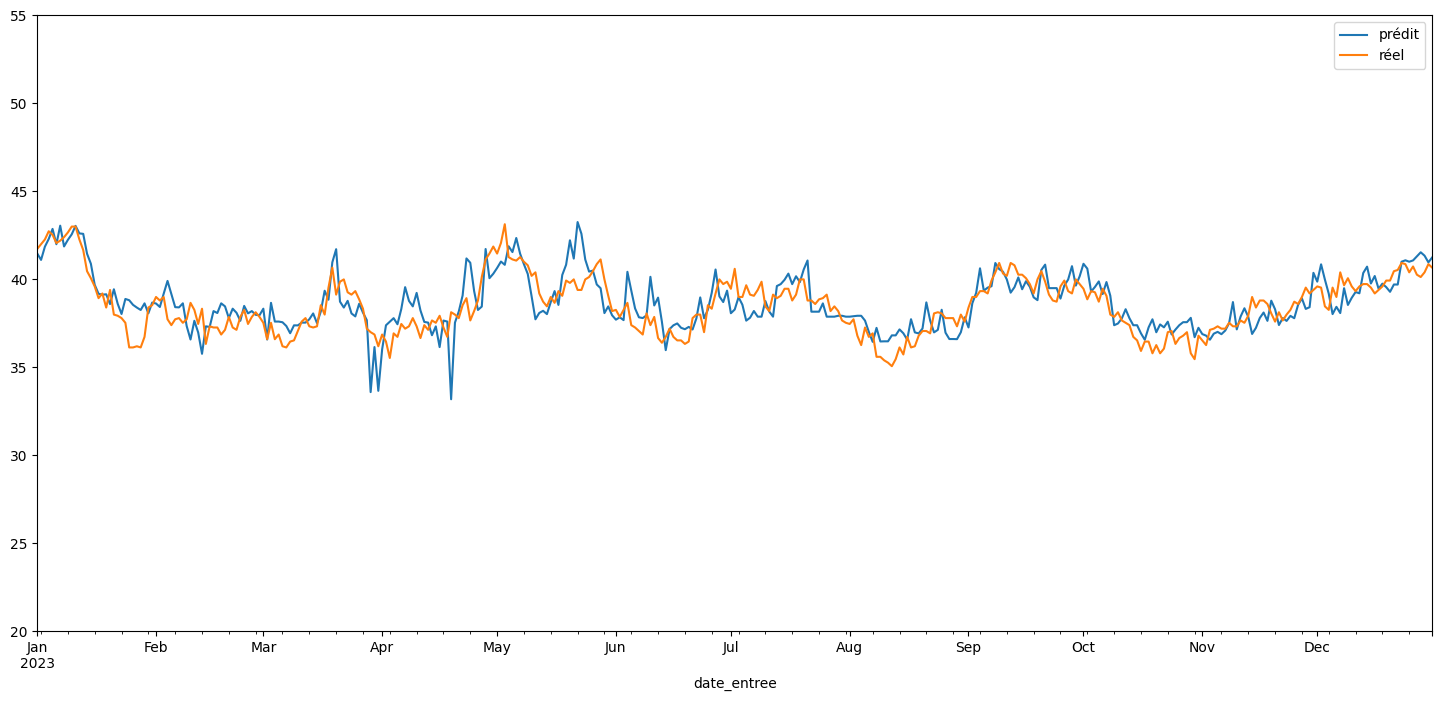

0.855319602285361
3/50: average-8
 -> amélioration: 1.7400 -> 1.6838
4/50: average-7
5/50: average-5
6/50: average-6
7/50: average-4
8/50: average-3
9/50: history-7
10/50: history-3
11/50: history-6
12/50: total_CHU Dijon_mean
 -> amélioration: 1.6838 -> 1.5889


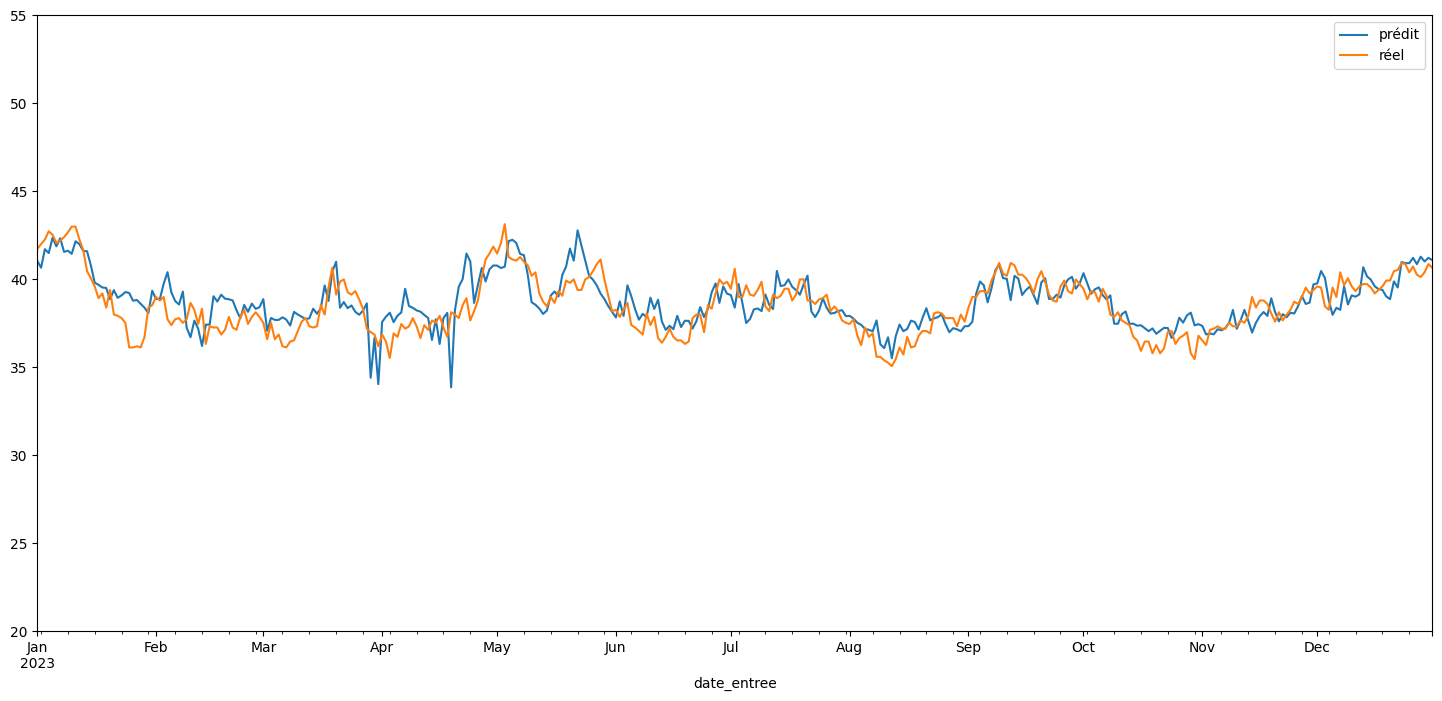

0.8475726087670944
13/50: history-4
14/50: inc_diarrhee_J-10
 -> amélioration: 1.5889 -> 1.4648
15/50: history-1
 -> amélioration: 1.4648 -> 1.4593


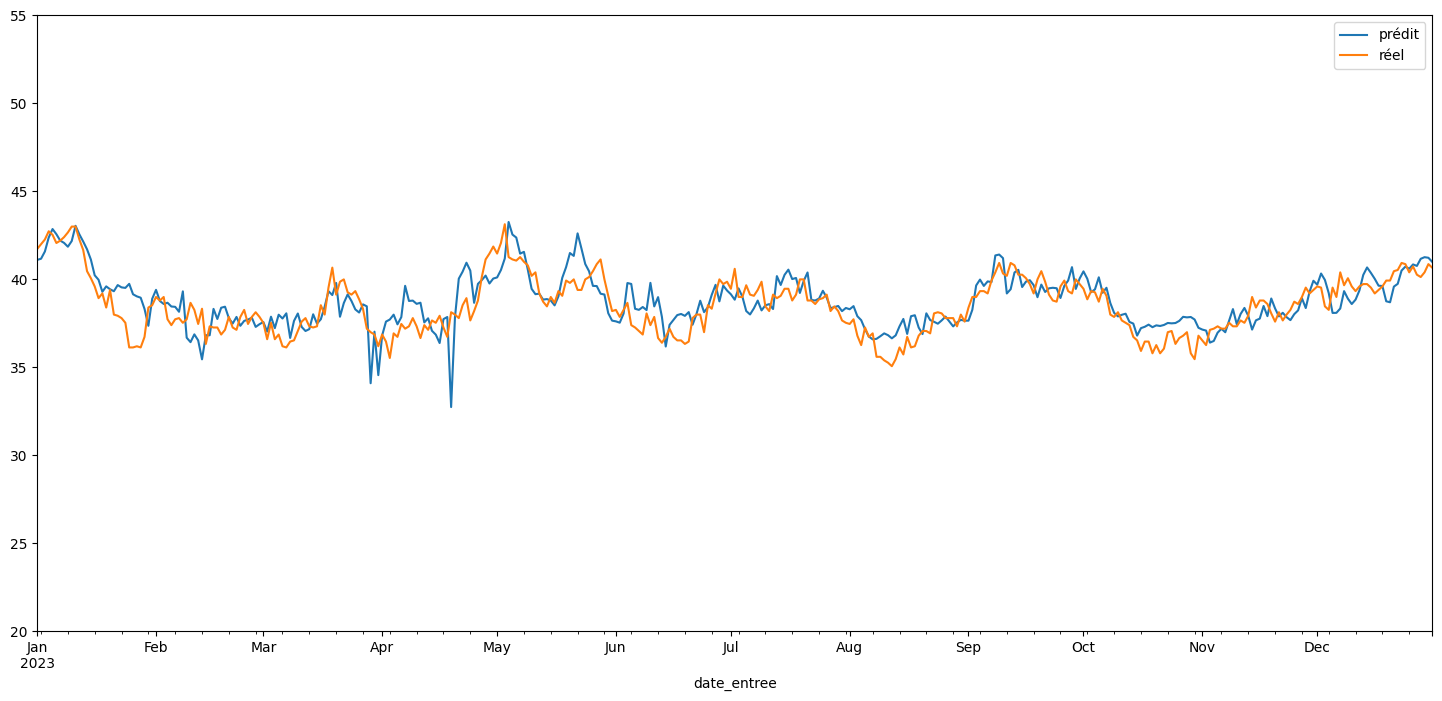

0.8531826853100718
16/50: average-2
17/50: inc_diarrhee_J-8
 -> amélioration: 1.4593 -> 1.4563
18/50: air_PM25_FR26094_std
19/50: year
 -> amélioration: 1.4563 -> 1.4493


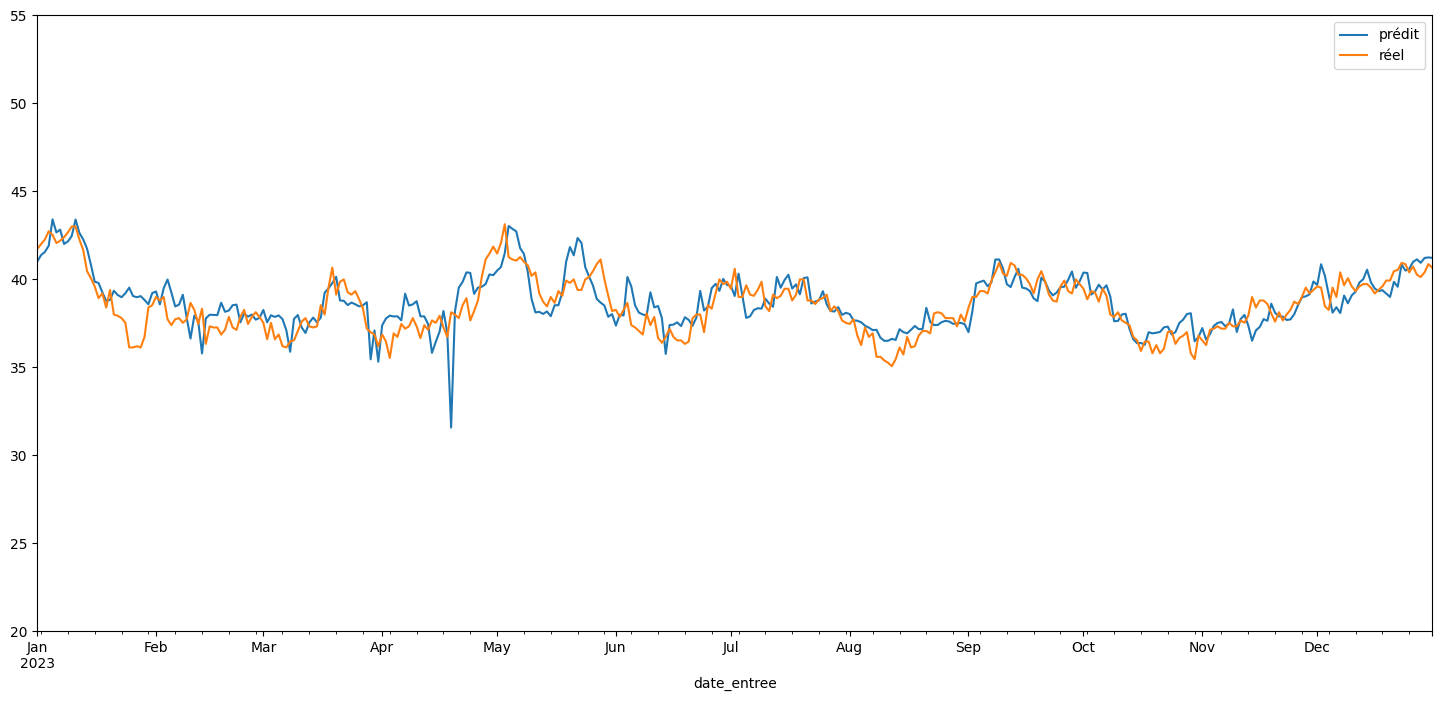

0.8191047268921343
20/50: history-5
 -> amélioration: 1.4493 -> 1.4167
21/50: inc_ira_J-11
 -> amélioration: 1.4167 -> 1.3777


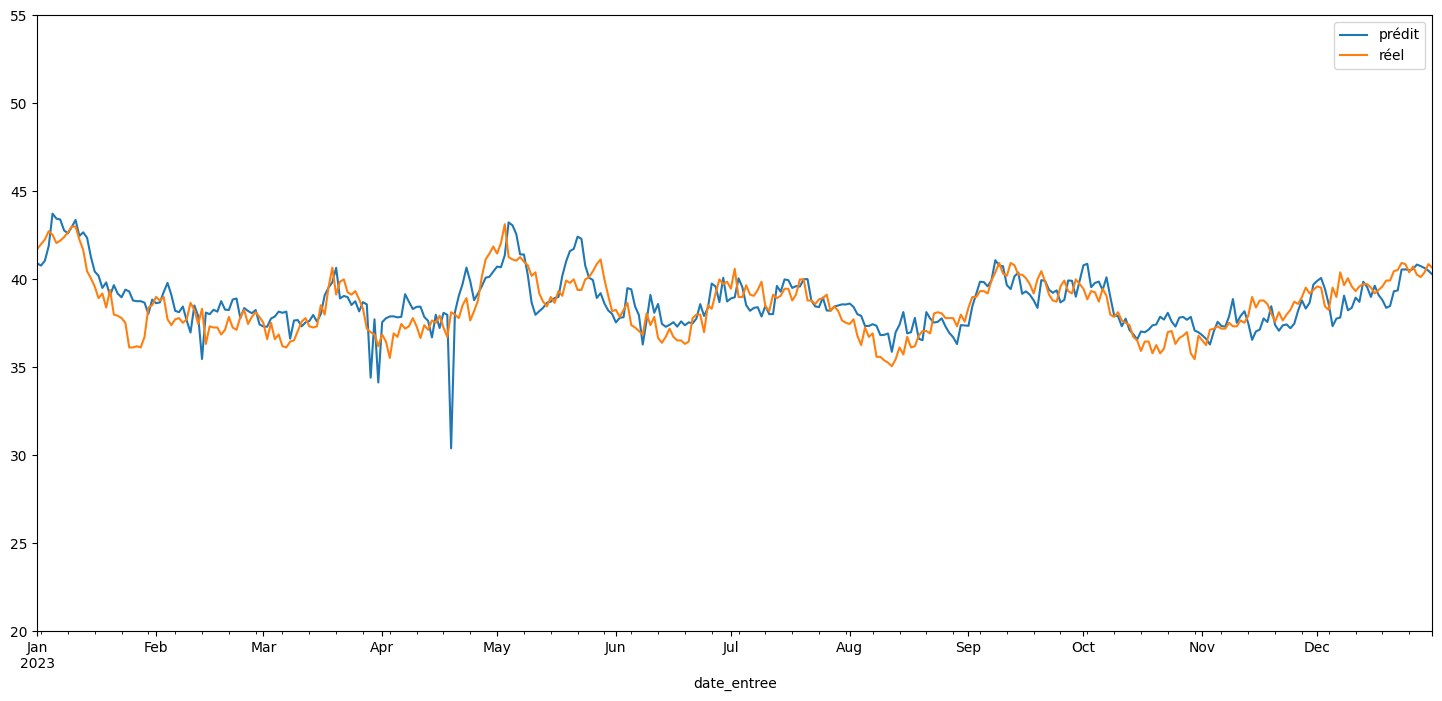

0.8884361586718392
22/50: total_CHU Dijon_J-7
23/50: inc_diarrhee_mean
 -> amélioration: 1.3777 -> 1.3739
24/50: inc_ira_std
 -> amélioration: 1.3739 -> 1.3728


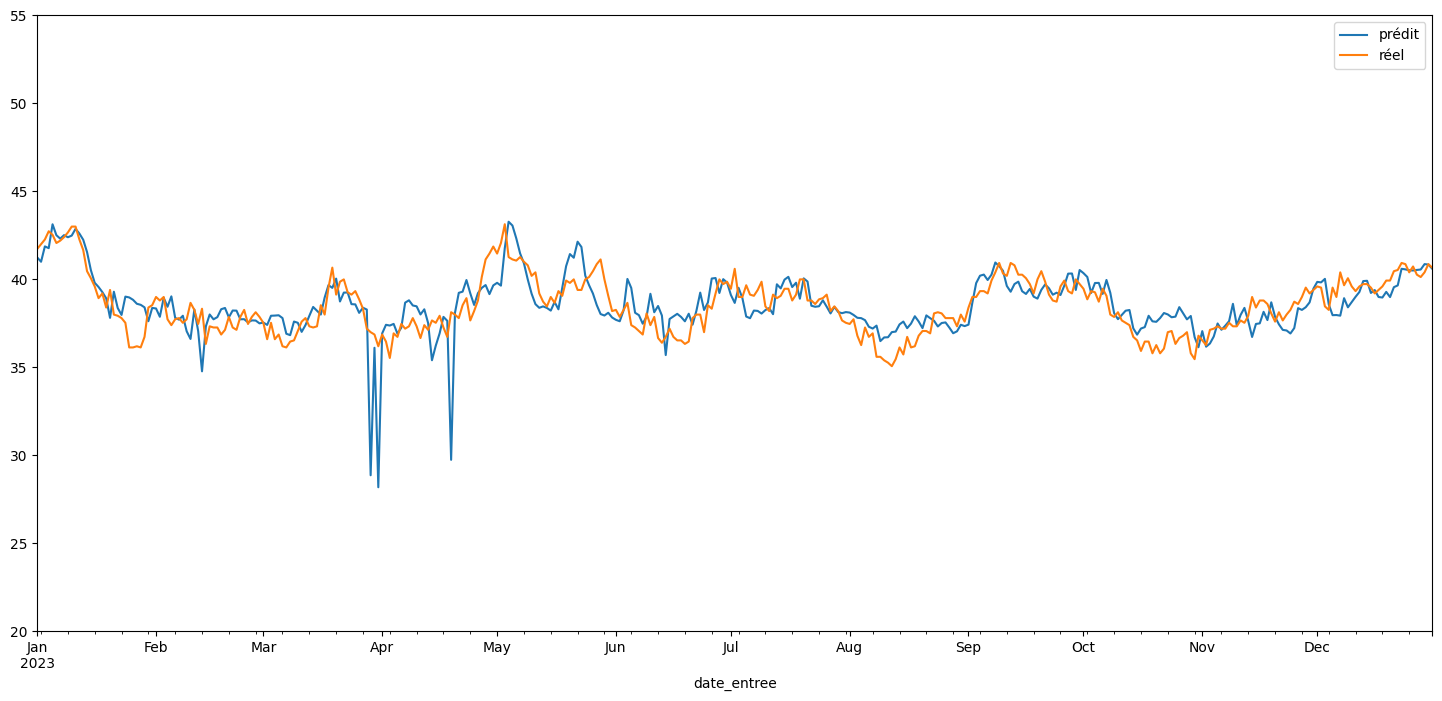

0.8905308996176241
25/50: inc_ira_J-12
 -> amélioration: 1.3728 -> 1.3533
26/50: history-2
27/50: inc_diarrhee_J-11
28/50: total_CHU Dijon_J-4
29/50: dayofweek
 -> amélioration: 1.3533 -> 1.3422


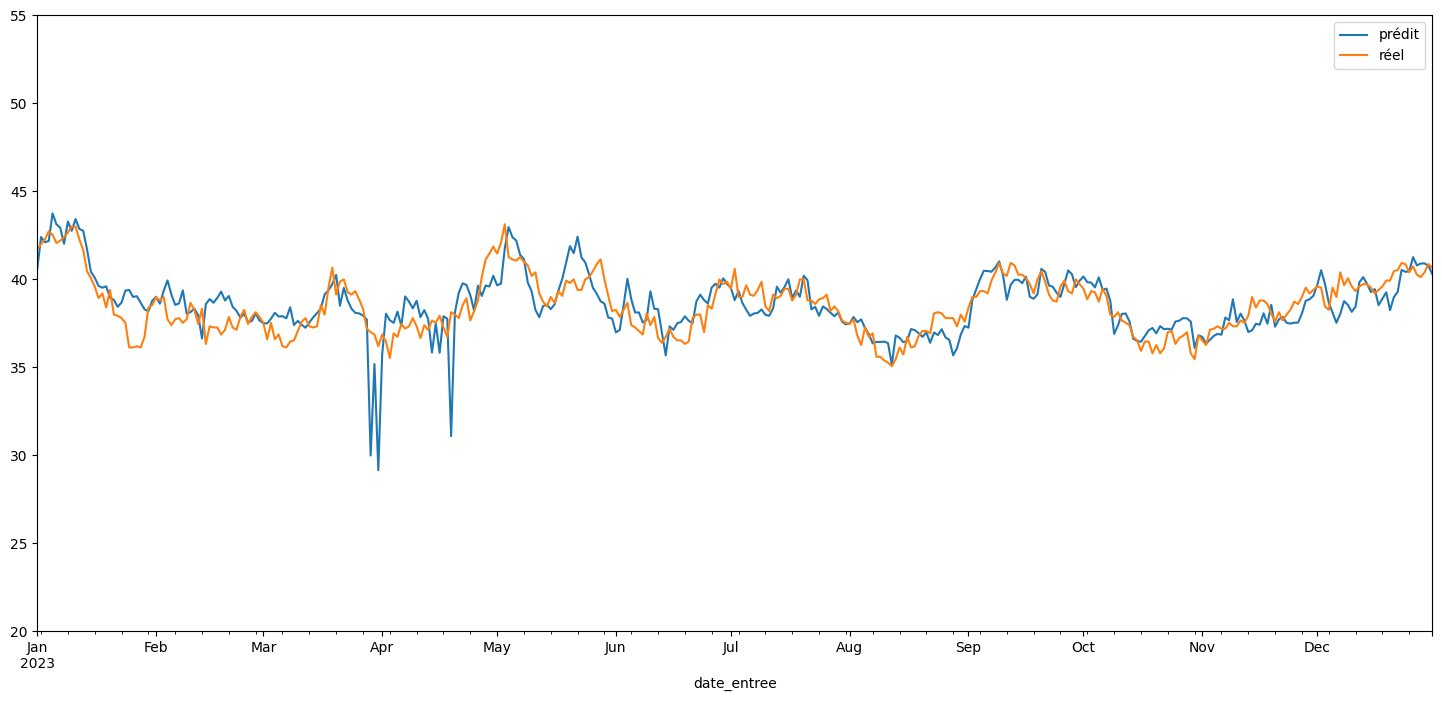

0.8797413049499845
30/50: air_NO2_FR26094_std
31/50: trend_AVC_std
 -> amélioration: 1.3422 -> 1.3377
32/50: confinement1
33/50: air_PM10_FR26094_std
 -> amélioration: 1.3377 -> 1.3098


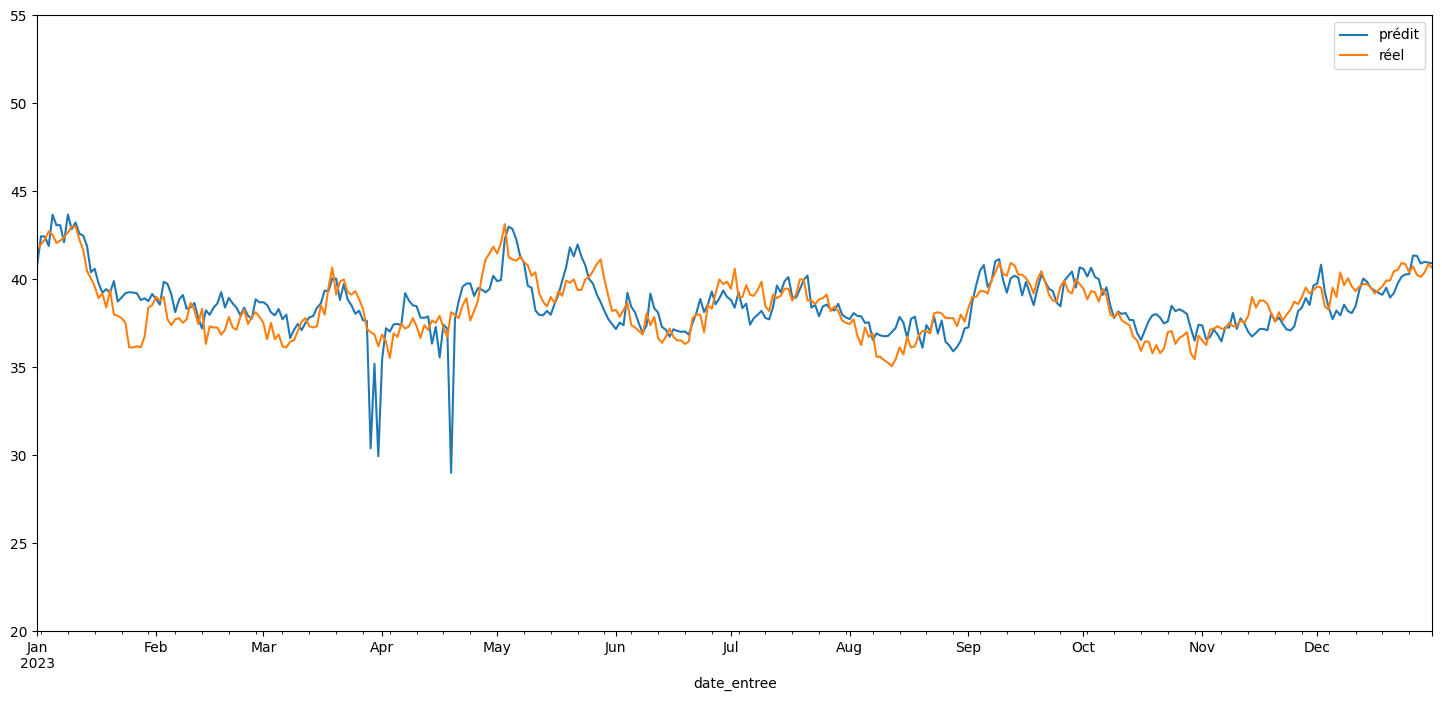

0.9189662777009557
34/50: inc_grippe_J-12
 -> amélioration: 1.3098 -> 1.3078
35/50: air_NO2_FR26094_J-7
36/50: total_CHU Dijon_J-5
37/50: inc_diarrhee_J-7
38/50: inc_diarrhee_J-5
 -> amélioration: 1.3078 -> 1.3045


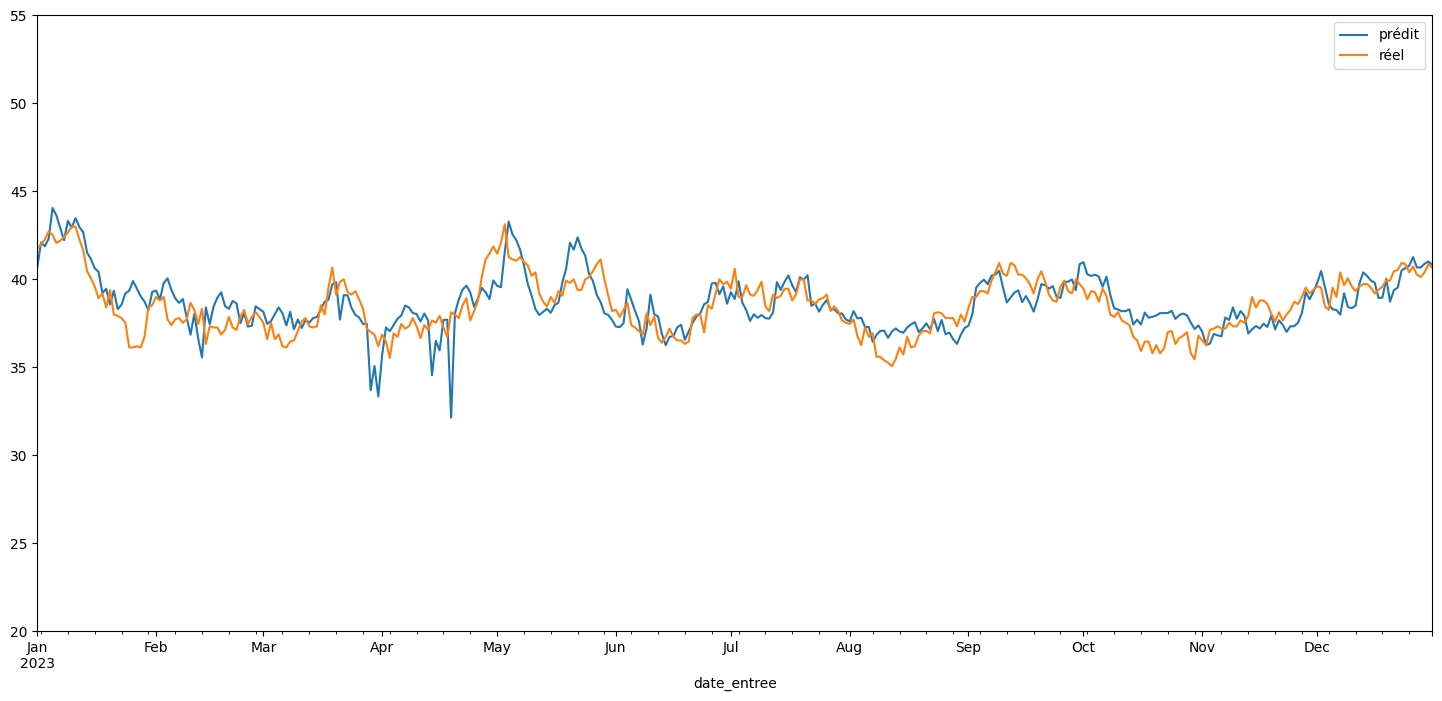

0.9396780232914158
39/50: inc_diarrhee_J-6
 -> amélioration: 1.3045 -> 1.2780
40/50: trend_pharmacie_J-5
41/50: air_NO2_FR26014_J-3
42/50: total_CHU Dijon_J-1
43/50: arrivees_urgences
 -> amélioration: 1.2780 -> 1.2599


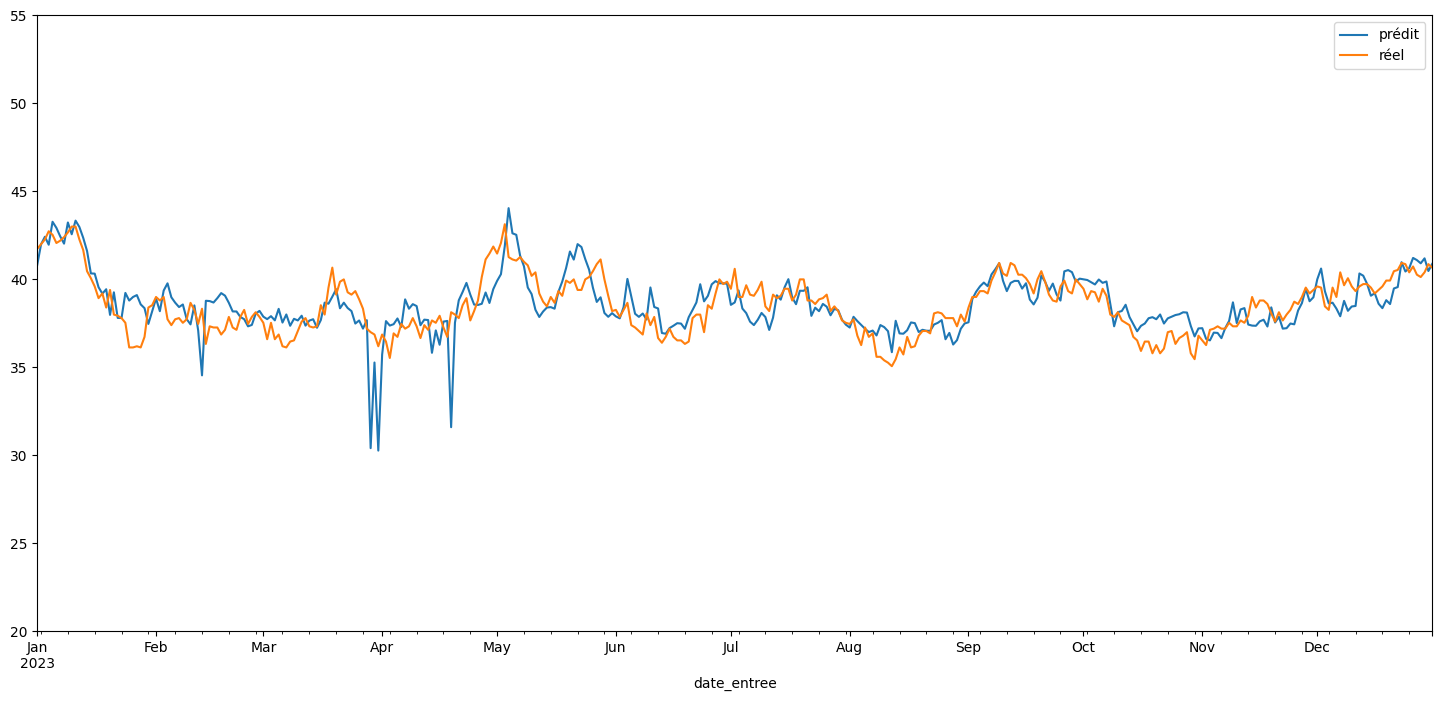

0.9120906725607285
44/50: total_CHU Dijon_J-6
45/50: inc_ira_J-10
46/50: meteo_CHU DIJON_0_tmax_mean
47/50: total_CHU Dijon_J-3
48/50: inc_ira_J-9
49/50: total_CHU Dijon_J-2
50/50: trend_diarrhée_std
 -> amélioration: 1.2599 -> 1.2566


In [475]:

mes_cols = []
score = 100
cpt = 1
for index, col in enumerate(liste):
    print(f"{index+1}/{len(liste)}: {col}")
    res = teste(dg[list(set(mes_cols+[col, 'target']))], params)
    if res[1] < score:
        print(f" -> amélioration: {score:.4f} -> {res[1]:.4f}")
        score = res[1]
        mes_cols.append(col)
        if cpt %2 == 0:
            global_year = {'predict': [], 'actual': []}
            for month in range(1, 12, 2):
                start = dt.datetime(2023,month,1)
                stop = start + dt.timedelta(days=60)
                teste_final(dg[mes_cols+['target']], params, start, stop, plot=False)
            plt.figure()
            dY = pd.DataFrame(global_year)
            dY = dY[:365].set_index(dg.loc[dg.index.year == 2023].index)
            dY['predict'].plot(label="prédit")
            dY['actual'].plot(label="réel")
            if type_target == 'hospitalisations':
                plt.ylim(20, 55)
            else:
                plt.ylim(125, 225)
            plt.legend()
            plt.show()
            print(mean_absolute_error(global_year['predict'], global_year['actual']))
        cpt += 1

In [476]:
3.95/dg.target.mean()

0.09823256650120622

In [477]:
predicted = global_year['predict'][1:]
actual = global_year['actual'][1:]

In [478]:
predicted_week = [statistics.mean(predicted[k:k+7]) for k in range(0, len(predicted), 7)]
actual_week = [statistics.mean(actual[k:k+7]) for k in range(0, len(predicted), 7)]
mean_absolute_error(predicted_week, actual_week)

0.6439027668009552

In [479]:
actual_week[:10]

[42.31428571428572,
 41.87619047619047,
 38.78095238095238,
 36.666666666666664,
 38.40952380952381,
 37.885714285714286,
 37.21904761904762,
 37.67619047619048,
 37.304761904761904,
 36.82857142857143]

In [480]:
predicted_week[:10]

[42.437134,
 42.346474,
 39.081367,
 38.697598,
 38.698433,
 38.067993,
 38.28772,
 37.910446,
 37.970356,
 37.6644]

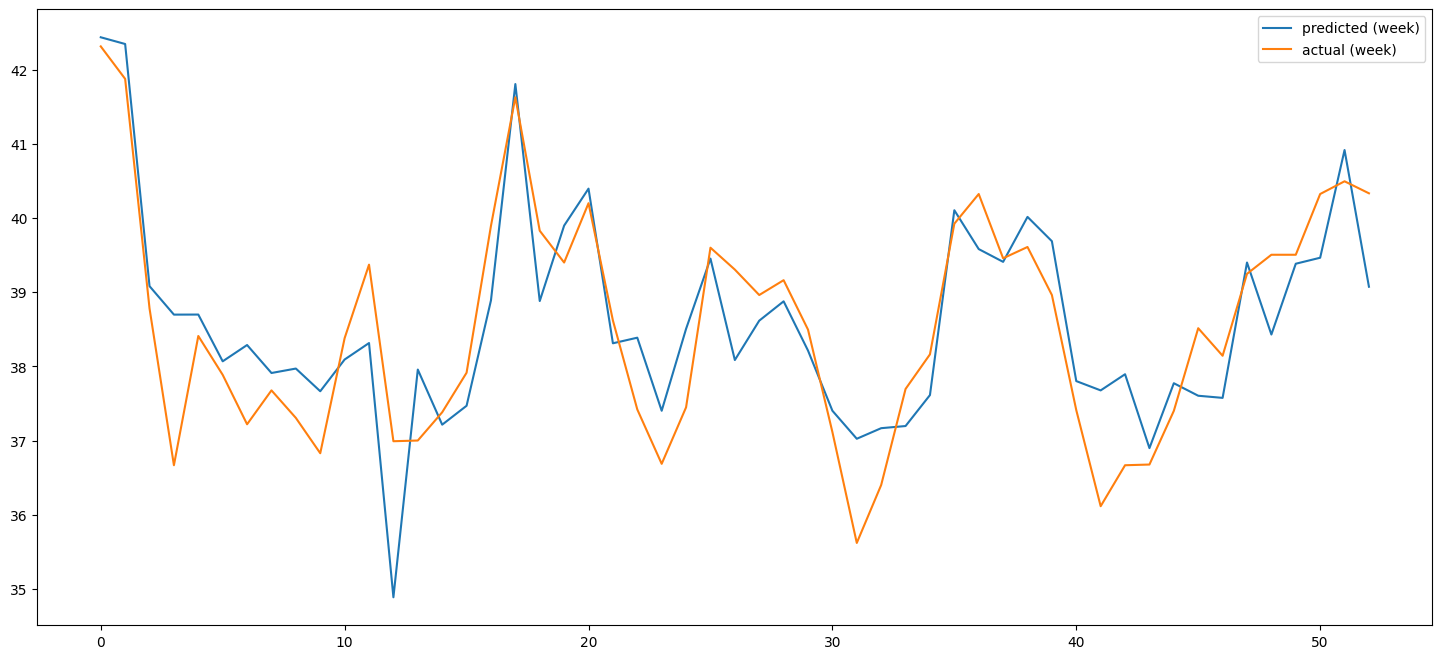

In [481]:
plt.plot(range(len(predicted_week)), predicted_week, label='predicted (week)')
plt.plot(range(len(actual_week)), actual_week, label='actual (week)')
plt.legend()

In [482]:
print("Pourcentage erreur relative : ")
mean_absolute_error(predicted, actual)/dg.target.mean()

Pourcentage erreur relative : 


0.022682707255859014

In [483]:
mes_cols

['month',
 'average-9',
 'average-8',
 'total_CHU Dijon_mean',
 'inc_diarrhee_J-10',
 'history-1',
 'inc_diarrhee_J-8',
 'year',
 'history-5',
 'inc_ira_J-11',
 'inc_diarrhee_mean',
 'inc_ira_std',
 'inc_ira_J-12',
 'dayofweek',
 'trend_AVC_std',
 'air_PM10_FR26094_std',
 'inc_grippe_J-12',
 'inc_diarrhee_J-5',
 'inc_diarrhee_J-6',
 'arrivees_urgences',
 'trend_diarrhée_std']

In [484]:
import pandas as pd
bjml = pd.read_csv('bjml.csv', sep=';')

In [485]:
len(predicted_week)

53

In [486]:
bjml['predicted'] = predicted_week[:-1]
bjml['predicted'] = bjml['predicted'].apply(lambda x: round(x, 2)) 
bjml['actual'] = actual_week[:-1]
bjml['actual'] = bjml['actual'].apply(lambda x: round(x,2))

In [487]:
dgg = dg.loc[dg.index.year == 2023]
dgg = dgg[1:]

In [488]:
dg.shape

(1826, 1111)

In [489]:
dgg = dgg[["month", "target"]]
#dg.set_index("date_entree", inplace=True)
resampled_df = dgg.resample('W', label='left', origin=dgg.index.min()).mean().reset_index()

In [490]:
mean_absolute_error(dgg.target[::7], bjml['Max.'])

15.392307692307694

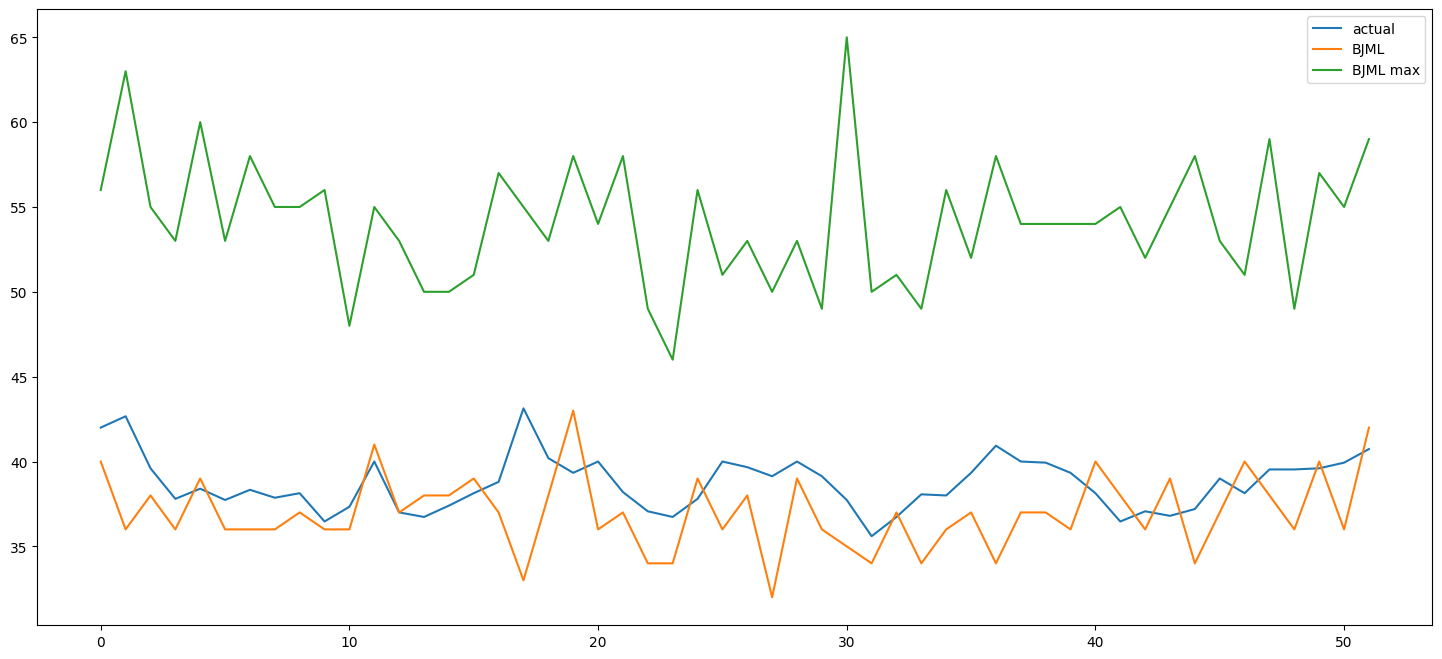

In [491]:
plt.plot(range(len(dgg.target[::7])), dgg.target[::7].values, label='actual')
plt.plot(range(len(bjml.BJML)), bjml.BJML, label='BJML') 
plt.plot(range(len(bjml.BJML)), bjml['Max.'], label='BJML max') 
plt.legend()

In [492]:
dg['target'][:7]

date_entree
2019-01-01    46.2
2019-01-02    46.2
2019-01-03    46.2
2019-01-04    46.2
2019-01-05    46.2
2019-01-06    46.2
2019-01-07    46.2
Name: target, dtype: float64

In [493]:
dg['target'][:7].mean()

46.199999999999996

In [494]:
bjml.BJML.iloc[0]

40

In [495]:
predicted = global_year['predict'][1:]
actual = global_year['actual'][1:]

In [496]:
predicted_week = [statistics.mean(predicted[k:k+7]) for k in range(0, len(predicted), 7)]
actual_week = [statistics.mean(actual[k:k+7]) for k in range(0, len(predicted), 7)]
mean_absolute_error(predicted_week, actual_week)

0.6439027668009552

In [497]:
import pandas as pd
bjml = pd.read_csv('bjml.csv', sep=';')

In [498]:
bjml['predicted'] = predicted_week[:-1]
bjml['predicted'] = bjml['predicted'].apply(lambda x: round(x, 2)) 
bjml['actual'] = actual_week[:-1]
bjml['actual'] = bjml['actual'].apply(lambda x: round(x,2))

In [499]:
mean_absolute_error(bjml['BJML'], bjml['actual'])

2.3194230769230773

In [500]:
mean_absolute_error(bjml['predicted'], bjml['actual'])

0.6319230769230764

In [501]:
bjml

,Semaine,Min.,BJML,Méd.,P75,Max.,predicted,actual
0,1,21,40,43,49,56,42.44,42.31
1,2,29,36,40,49,63,42.35,41.88
2,3,28,38,44,49,55,39.08,38.78
3,4,25,36,40,44,53,38.70,36.67
4,5,31,39,43,45,60,38.70,38.41
5,6,31,36,39,44,53,38.07,37.89
6,7,28,36,40,44,58,38.29,37.22
7,8,32,36,38,43,55,37.91,37.68
8,9,33,37,43,46,55,37.97,37.30
9,10,26,36,40,43,56,37.66,36.83


In [502]:
bjml[['Semaine', 'BJML', 'predicted', 'actual']]

,Semaine,BJML,predicted,actual
0,1,40,42.44,42.31
1,2,36,42.35,41.88
2,3,38,39.08,38.78
3,4,36,38.70,36.67
4,5,39,38.70,38.41
5,6,36,38.07,37.89
6,7,36,38.29,37.22
7,8,36,37.91,37.68
8,9,37,37.97,37.30
9,10,36,37.66,36.83
